# **Sentiment Classification Using BERT**
BERT is a language model developed by Google in 2018 that revolutionized how machines understand human language. Its key innovation is bidirectional training – reading text in both directions (left-to-right and right-to-left) simultaneously.

### **BERT Architecture**

Two main versions:

- **BERT-base:** 12 layers, 110 million parameters
- **BERT-large:** 24 layers, 340 million parameters

In [1]:
import os
import shutil
import tarfile
import tensorflow as tf
from transformers import BertTokenizer, TFBertForSequenceClassification
import pandas as pd
from bs4 import BeautifulSoup
import re
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.offline as pyo
import plotly.graph_objects as go
from wordcloud import WordCloud, STOPWORDS
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

### **Step 2: Load the dataset**

In [2]:
current_folder = os.getcwd()

dataset = tf.keras.utils.get_file(
    fname ="aclImdb.tar.gz", 
    origin ="http://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz",
    cache_dir=  current_folder,
    extract = True)

**Check the dataset folder**

In [3]:
dataset_path = os.path.dirname(dataset)
os.listdir(dataset_path)

['aclImdb_extracted', 'aclImdb', 'aclImdb.tar.gz']

**Check the 'aclImdb' directory**

In [4]:
dataset_dir = os.path.join(dataset_path, 'aclImdb_extracted/aclImdb')

os.listdir(dataset_dir)

['imdbEr.txt', 'test', 'imdb.vocab', 'README', 'train']

**Check the 'Train' dataset folder**

In [5]:
train_dir = os.path.join(dataset_dir,'train')
os.listdir(train_dir)

['urls_unsup.txt',
 'neg',
 'urls_pos.txt',
 'unsup',
 'urls_neg.txt',
 'pos',
 'unsupBow.feat',
 'labeledBow.feat']

**Read the files of the 'Train' directory files**

In [6]:
for file in os.listdir(train_dir):
    file_path = os.path.join(train_dir, file)
    if os.path.isfile(file_path): 
        with open(file_path, 'r', encoding='utf-8') as f:
            first_value = f.readline().strip()
            print(f"{file}: {first_value}")
    else:
        print(f"{file}: {file_path}")

urls_unsup.txt: http://www.imdb.com/title/tt0018515/usercomments
neg: /Users/tannutiwari/Downloads/Projects/Jupyter/datasets/aclImdb_extracted/aclImdb/train/neg
urls_pos.txt: http://www.imdb.com/title/tt0453418/usercomments
unsup: /Users/tannutiwari/Downloads/Projects/Jupyter/datasets/aclImdb_extracted/aclImdb/train/unsup
urls_neg.txt: http://www.imdb.com/title/tt0064354/usercomments
pos: /Users/tannutiwari/Downloads/Projects/Jupyter/datasets/aclImdb_extracted/aclImdb/train/pos
unsupBow.feat: 0 0:8 1:6 3:5 4:2 5:1 7:1 8:5 9:2 10:1 11:2 13:3 16:1 17:1 18:1 19:1 22:3 24:1 26:3 28:1 30:1 31:1 35:2 36:1 39:2 40:1 41:2 46:2 47:1 48:1 52:1 63:1 67:1 68:1 74:1 81:1 83:1 87:1 104:1 105:1 112:1 117:1 131:1 151:1 155:1 170:1 198:1 225:1 226:1 288:2 291:1 320:1 331:1 342:1 364:1 374:1 384:2 385:1 407:1 437:1 441:1 465:1 468:1 470:1 519:1 595:1 615:1 650:1 692:1 851:1 937:1 940:1 1100:1 1264:1 1297:1 1317:1 1514:1 1728:1 1793:1 1948:1 2088:1 2257:1 2358:1 2584:2 2645:1 2735:1 3050:1 4297:1 5385:1 

**Load the Movies reviews and convert them into the pandas' data frame with their respective sentiment**

Here 0 means Negative and 1 means Positive

In [7]:
def load_dataset(directory):
    data = {"sentence": [], "sentiment": []}
    for file_name in os.listdir(directory):
        print(file_name)
        if file_name == 'pos':
            positive_dir = os.path.join(directory, file_name)
            for text_file in os.listdir(positive_dir):
                text = os.path.join(positive_dir, text_file)
                with open(text, "r", encoding="utf-8") as f:
                    data["sentence"].append(f.read())
                    data["sentiment"].append(1)
        elif file_name == 'neg':
            negative_dir = os.path.join(directory, file_name)
            for text_file in os.listdir(negative_dir):
                text = os.path.join(negative_dir, text_file)
                with open(text, "r", encoding="utf-8") as f:
                    data["sentence"].append(f.read())
                    data["sentiment"].append(0)
            
    return pd.DataFrame.from_dict(data)

**Load the training datasets**

In [8]:
train_df = load_dataset(train_dir)
print(train_df.head())

urls_unsup.txt
neg
urls_pos.txt
unsup
urls_neg.txt
pos
unsupBow.feat
labeledBow.feat
                                            sentence  sentiment
0  Working with one of the best Shakespeare sourc...          0
1  Well...tremors I, the original started off in ...          0
2  Ouch! This one was a bit painful to sit throug...          0
3  I've seen some crappy movies in my life, but t...          0
4  "Carriers" follows the exploits of two guys an...          0


**Load the test dataset respectively**

In [9]:
test_dir = os.path.join(dataset_dir,'test')
test_df = load_dataset(test_dir)
print(test_df.head())

neg
urls_pos.txt
urls_neg.txt
pos
labeledBow.feat
                                            sentence  sentiment
0  Alan Rickman & Emma Thompson give good perform...          0
1  I have seen this movie and I did not care for ...          0
2  In Los Angeles, the alcoholic and lazy Hank Ch...          0
3  This film is bundled along with "Gli fumavano ...          0
4  I only comment on really very good films and o...          0


### **Step 3: Preprocessing**

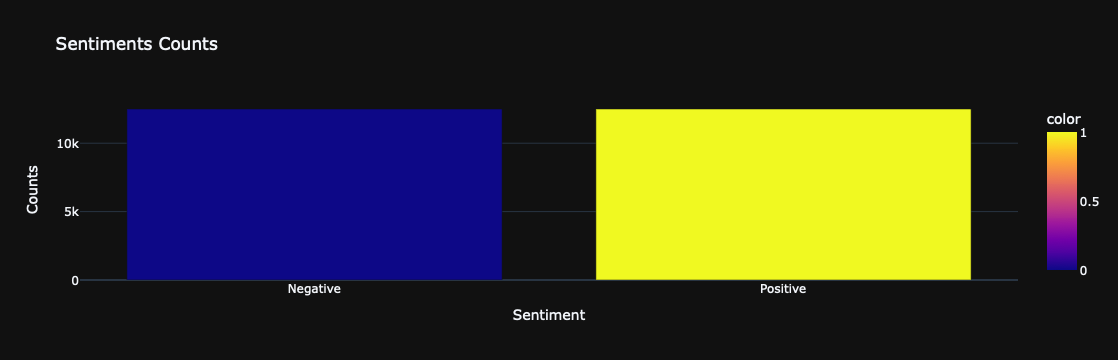

'Sentiments Counts.html'

In [10]:
sentiment_counts = train_df['sentiment'].value_counts()

fig =px.bar(x= {0:'Negative',1:'Positive'},
            y= sentiment_counts.values,
            color=sentiment_counts.index,
            color_discrete_sequence =  px.colors.qualitative.Dark24,
            title='<b>Sentiments Counts')

fig.update_layout(title='Sentiments Counts',
                  xaxis_title='Sentiment',
                  yaxis_title='Counts',
                  template='plotly_dark')


fig.show()
pyo.plot(fig, filename = 'Sentiments Counts.html', auto_open = True)

**Text Cleaning**

In [11]:
def text_cleaning(text):
    soup = BeautifulSoup(text, "html.parser")
    text = re.sub(r'\[[^]]*\]', '', soup.get_text())
    pattern = r"[^a-zA-Z0-9\s,']"
    text = re.sub(pattern, '', text)
    return text

**Apply text_cleaning**

In [12]:
train_df['Cleaned_sentence'] = train_df['sentence'].apply(text_cleaning).tolist()
test_df['Cleaned_sentence'] = test_df['sentence'].apply(text_cleaning)

**Plot reviews on WordCLouds**

In [13]:
def generate_wordcloud(text,Title):
    all_text = " ".join(text)
    wordcloud = WordCloud(width=800, 
                          height=400,
                          stopwords=set(STOPWORDS), 
                          background_color='black').generate(all_text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(Title)
    plt.show()

**Positive Reviews**

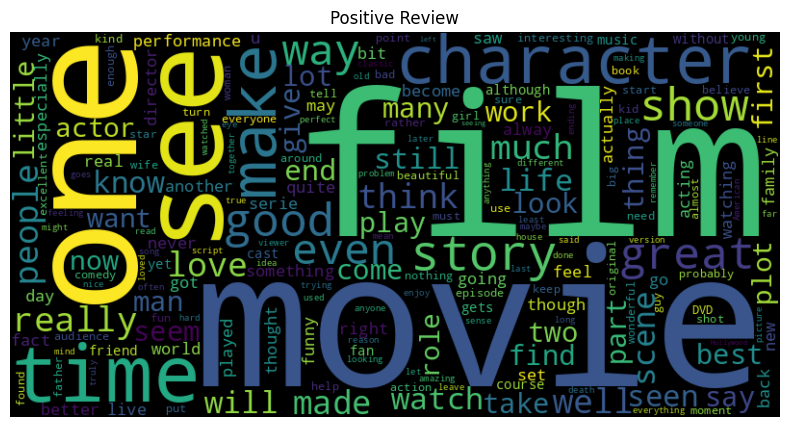

In [14]:
positive = train_df[train_df['sentiment']==1]['Cleaned_sentence'].tolist()
generate_wordcloud(positive,'Positive Review')

**Negative Reviews**

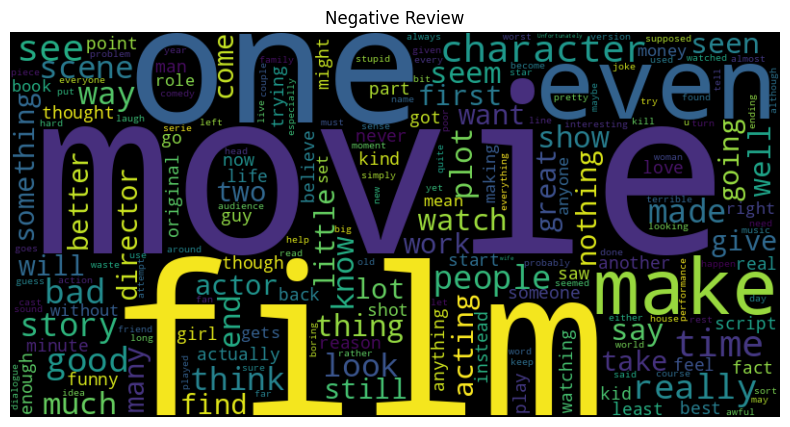

In [15]:
negative = train_df[train_df['sentiment']==0]['Cleaned_sentence'].tolist()
generate_wordcloud(negative,'Negative Review')

**Separate input text and target sentiment of both train and test**

In [16]:
Reviews = train_df['Cleaned_sentence']
Target = train_df['sentiment']

test_reviews = test_df['Cleaned_sentence']
test_targets = test_df['sentiment']

**Split TEST data into test and validation**

In [17]:
x_val, x_test, y_val, y_test = train_test_split(test_reviews,
                                                    test_targets,
                                                    test_size=0.5, 
                                                    stratify = test_targets)

### **Step 4: Tokenization & Encoding**

BERT tokenization is used to convert the raw text into numerical inputs that can be fed into the BERT model. It tokenized the text and performs some preprocessing to prepare the text for the model's input format. Let's understand some of the key features of the BERT tokenization model.

BERT tokenizer splits the words into subwords or workpieces. For example, the word "geeksforgeeks" can be split into "youtube" "##for", and"##youtube". The "##" prefix indicates that the subword is a continuation of the previous one. It reduces the vocabulary size and helps the model to deal with rare or unknown words.

BERT tokenizer adds special tokens like **[CLS]**, **[SEP]**, and **[MASK]** to the sequence. These tokens have special meanings like :
- **[CLS]** is used for classifications and to represent the entire input in the case of sentiment analysis,
- **[SEP]** is used as a separator i.e. to mark the boundaries between different sentences or segments,
- **[MASK]** is used for masking i.e. to hide some tokens from the model during pre-training.

BERT tokenizer gives their components as outputs:
- input_ids: The numerical identifiers of the vocabulary tokens
- token_type_ids: It identifies which segment or sentence each token belongs to.
- attention_mask: It flags that inform the model which tokens to pay attention to and which to disregard.

In [18]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased', do_lower_case=True)

**Apply the BERT tokenization in training, testing and validation dataset**

In [19]:
max_len= 128
X_train_encoded = tokenizer.batch_encode_plus(Reviews.tolist(),
                                              padding=True, 
                                              truncation=True,
                                              max_length = max_len,
                                              return_tensors='tf')

X_val_encoded = tokenizer.batch_encode_plus(x_val.tolist(), 
                                              padding=True, 
                                              truncation=True,
                                              max_length = max_len,
                                              return_tensors='tf')

X_test_encoded = tokenizer.batch_encode_plus(x_test.tolist(), 
                                              padding=True, 
                                              truncation=True,
                                              max_length = max_len,
                                              return_tensors='tf')

**Check the encoded dataset**

In [20]:
k = 0
print('Training Comments -->>',Reviews[k])
print('\nInput Ids -->>\n',X_train_encoded['input_ids'][k])
print('\nDecoded Ids -->>\n',tokenizer.decode(X_train_encoded['input_ids'][k]))
print('\nAttention Mask -->>\n',X_train_encoded['attention_mask'][k])
print('\nLabels -->>',Target[k])

Training Comments -->> Working with one of the best Shakespeare sources, this film manages to be creditable to it's source, whilst still appealing to a wider audienceBranagh steals the film from under Fishburne's nose, and there's a talented cast on good form

Input Ids -->>
 tf.Tensor(
[  101  2551  2007  2028  1997  1996  2190  8101  4216  1010  2023  2143
  9020  2000  2022  4923  3085  2000  2009  1005  1055  3120  1010  5819
  2145 16004  2000  1037  7289  4378 10024  2532  5603 15539  1996  2143
  2013  2104  3869  8022  2063  1005  1055  4451  1010  1998  2045  1005
  1055  1037 10904  3459  2006  2204  2433   102     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0 

### **Step 5: Build the classification model**

In [21]:
model = TFBertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)

All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


**Compile the model**

In [22]:
optimizer = tf.keras.optimizers.legacy.Adam(learning_rate=2e-5)
loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
metric = tf.keras.metrics.SparseCategoricalAccuracy('accuracy')
model.compile(optimizer=optimizer, loss=loss, metrics=[metric])

**Train the model**

In [ ]:
history = model.fit(
    [X_train_encoded['input_ids'], X_train_encoded['token_type_ids'], X_train_encoded['attention_mask']],
    Target,
    validation_data=(
      [X_val_encoded['input_ids'], X_val_encoded['token_type_ids'], X_val_encoded['attention_mask']],y_val),
    batch_size=32,
    epochs=3
)

### **Step 6:Evaluate the model**

In [ ]:
test_loss, test_accuracy = model.evaluate(
    [X_test_encoded['input_ids'], X_test_encoded['token_type_ids'], X_test_encoded['attention_mask']],
    y_test
)
print(f'Test loss: {test_loss}, Test accuracy: {test_accuracy}')

**Save the model and tokenizer to the local folder**

In [ ]:
path = '/content'
tokenizer.save_pretrained(path +'/Tokenizer')
model.save_pretrained(path +'/Model')

**Load the model and tokenizer from the local folder**

In [ ]:
bert_tokenizer = BertTokenizer.from_pretrained(path +'/Tokenizer')
bert_model = TFBertForSequenceClassification.from_pretrained(path +'/Model')

**Predict the sentiment of the test dataset**

In [ ]:
pred = bert_model.predict(
    [X_test_encoded['input_ids'], X_test_encoded['token_type_ids'], X_test_encoded['attention_mask']])
logits = pred.logits

pred_labels = tf.argmax(logits, axis=1)

pred_labels = pred_labels.numpy()

label = {
    1: 'positive',
    0: 'Negative'
}

pred_labels = [label[i] for i in pred_labels]
Actual = [label[i] for i in y_test]

print('Predicted Label :', pred_labels[:10])
print('Actual Label    :', Actual[:10])

**Classification Report**

In [ ]:
print("Classification Report: \n", classification_report(Actual, pred_labels))

### **Step 7: Prediction with user inputs**

In [ ]:
def Get_sentiment(Review, Tokenizer=bert_tokenizer, Model=bert_model):
    if not isinstance(Review, list):
        Review = [Review]

    Input_ids, Token_type_ids, Attention_mask = Tokenizer.batch_encode_plus(Review,
                                                                             padding=True,
                                                                             truncation=True,
                                                                             max_length=128,
                                                                             return_tensors='tf').values()
    prediction = Model.predict([Input_ids, Token_type_ids, Attention_mask])

    pred_labels = tf.argmax(prediction.logits, axis=1)
    pred_labels = [label[i] for i in pred_labels.numpy().tolist()]
    return pred_labels

In [ ]:
Review ='''Bahubali is a blockbuster Indian movie that was released in 2015. 
It is the first part of a two-part epic saga that tells the story of a legendary hero who fights for his kingdom and his love. 
The movie has received rave reviews from critics and audiences alike for its stunning visuals, 
spectacular action scenes, and captivating storyline.'''
Get_sentiment(Review)